# ME712 – DII pediátrica (HC-Unicamp): Análise bivariada em gráficos

Gera as figuras (`figuras/*.pdf`) e a tabela-resumo dos testes (`tabelas/tab_resumo_testes.tex`)
usadas na seção de Análise Bivariada do relatório.

**Como usar no Colab:** rode as células em ordem. Na célula de leitura, faça o upload de
`Data Set - TABELA TCC ESTATISTICA atualizada.xlsx`. A última célula baixa um `.zip` com figuras e tabela.

In [1]:
import os, glob, shutil
import numpy as np
import pandas as pd
from scipy import stats
from scipy.special import gammaln
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter, PercentFormatter
from statsmodels.nonparametric.smoothers_lowess import lowess

SEED = 712
rng = np.random.default_rng(SEED)
os.makedirs("tabelas", exist_ok=True)
os.makedirs("figuras", exist_ok=True)

# Se True, exclui o paciente sem registro do tempo até a consulta de TODAS as análises
# (n = 100, como na análise univariada). Se False, ele só sai da comparação consulta x colonoscopia.
EXCLUIR_SEM_CONSULTA = True

## 1. Leitura e padronização

In [ ]:
try:                                    # no Colab: janela de upload
    from google.colab import files
    enviado = files.upload()
    ARQ = next(iter(enviado))
except ImportError:                     # fora do Colab: ajuste o caminho
    ARQ = "Data Set - TABELA TCC ESTATISTICA atualizada.xlsx"

bruto = pd.read_excel(ARQ, sheet_name="Tabela").iloc[:, :17]
bruto = bruto[bruto.iloc[:, 0].notna()].copy()
bruto.columns = ["id", "sexo", "classe_idade", "dt_nasc", "idade_inicio",
                 "dt_inicio", "t_consulta", "t_consulta_rc", "dif_consulta",
                 "sintoma", "perda_peso", "dt_consulta", "t_colono",
                 "t_colono_rc", "dif_colono", "dt_colono", "diagnostico"]

NIV_SEXO  = ["Feminino", "Masculino"]
NIV_IDADE = ["VEO-IBD (< 6 a)", "Início precoce (6-9 a)", "Pediátrica (10-17 a)"]
NIV_SINT  = ["Diarreia", "Sangramento retal", "Dor abdominal", "Outros"]
NIV_SN    = ["Sim", "Não"]
NIV_DX    = ["DC", "CU", "CNC"]

def grupo_sintoma(s):
    s = str(s).strip()
    if s == "Diarreia":
        return "Diarreia"
    if s in ("Enterorragia", "Hematoquezia"):
        return "Sangramento retal"
    if s == "Dor abdominal":
        return "Dor abdominal"
    return "Outros"

cat = lambda x, niv: pd.Categorical(x, categories=niv, ordered=True)

dados = pd.DataFrame({
    "id": bruto["id"].astype(int),
    "sexo": cat(bruto["sexo"].str.strip().map({"F": "Feminino", "M": "Masculino"}), NIV_SEXO),
    "classe_idade": cat(bruto["classe_idade"].str.strip().map(
        {"VEOIBD": NIV_IDADE[0], "Início precoce": NIV_IDADE[1], "DI Ped": NIV_IDADE[2]}), NIV_IDADE),
    "sintoma_orig": bruto["sintoma"].str.strip(),
    "sintoma": cat(bruto["sintoma"].map(grupo_sintoma), NIV_SINT),
    "perda_peso": cat(np.where(bruto["perda_peso"].str.strip().str.lower() == "sim", "Sim", "Não"), NIV_SN),
    "diagnostico": cat(bruto["diagnostico"].str.strip(), NIV_DX),
    "idade_inicio": bruto["idade_inicio"].astype(float),
    "t_consulta": pd.to_numeric(bruto["t_consulta"], errors="coerce"),   # "?" -> NaN
    "t_dx": bruto["t_colono"].astype(float),                             # tempo até diagnóstico
})
dados["sangramento"] = cat(np.where(dados["sintoma"] == "Sangramento retal", "Sim", "Não"), NIV_SN)
dados["idade_inicio_anos"] = dados["idade_inicio"] / 12

if EXCLUIR_SEM_CONSULTA:
    dados = dados[dados["t_consulta"].notna()].reset_index(drop=True)

assert dados[["sexo", "classe_idade", "diagnostico", "perda_peso", "sintoma"]].notna().all().all()
N = len(dados)
print("n =", N)

## 2. Testes e funções auxiliares

In [ ]:
def fnum(x, d=1):
    return f"{x:.{d}f}".replace(".", ",")

def fmed(x):          # mediana: sem casas decimais se inteira
    return fnum(x, 0) if float(x).is_integer() else fnum(x, 1)

def ptxt(p):          # p-valor para os gráficos
    return "p < 0,001" if p < 0.001 else f"p = {fnum(p, 3)}"

def ptex(p):          # p-valor para o LaTeX
    return "$<$ 0,001" if p < 0.001 else fnum(p, 3)


def fisher_mc(tab, B=100_000):
    """Fisher r x c por Monte Carlo (mesma estatística do R, simulate.p.value = TRUE)."""
    tab = np.asarray(tab)
    r, c = tab.shape
    linhas = np.repeat(np.arange(r), tab.sum(1))
    colunas = np.repeat(np.arange(c), tab.sum(0))
    estat = lambda cont: -gammaln(cont + 1).sum(axis=-1)
    obs = estat(tab.ravel())
    sim = np.empty(B)
    lote = 20_000
    for ini in range(0, B, lote):
        b = min(lote, B - ini)
        perm = rng.permuted(np.tile(colunas, (b, 1)), axis=1)
        idx = linhas[None, :] * c + perm
        cont = np.apply_along_axis(np.bincount, 1, idx, minlength=r * c)
        sim[ini:ini + b] = estat(cont)
    return (1 + np.sum(sim <= obs / (1 + 64 * np.finfo(float).eps))) / (B + 1)


def teste_assoc(x, y):
    """Qui-quadrado se todas as esperadas >= 5; caso contrário, Fisher. Retorna também V de Cramér."""
    tab = pd.crosstab(x, y).values
    chi2, p_chi, gl, esp = stats.chi2_contingency(tab, correction=False)
    V = np.sqrt(chi2 / (tab.sum() * (min(tab.shape) - 1)))
    if (esp >= 5).all():
        return dict(teste="Qui-quadrado", p=p_chi, ef=V, ef_nome="V de Cramér")
    p = stats.fisher_exact(tab)[1] if tab.shape == (2, 2) else fisher_mc(tab)
    return dict(teste="Exato de Fisher", p=p, ef=V, ef_nome="V de Cramér")


def holm(p):
    p = np.asarray(p); m = len(p); o = np.argsort(p)
    adj = np.empty(m)
    adj[o] = np.minimum(1, np.maximum.accumulate((m - np.arange(m)) * p[o]))
    return adj


def dunn(y, g, niveis):
    """Teste de Dunn (com correção de empates) e ajuste de Holm."""
    y = np.asarray(y, float); g = np.asarray(g).astype(str)
    r = stats.rankdata(y); n = len(y)
    _, emp = np.unique(y, return_counts=True)
    S2 = n * (n + 1) / 12 - (emp**3 - emp).sum() / (12 * (n - 1))
    res = []
    for i in range(len(niveis)):
        for j in range(i + 1, len(niveis)):
            a, b = niveis[i], niveis[j]
            ra, rb = r[g == a], r[g == b]
            z = (ra.mean() - rb.mean()) / np.sqrt(S2 * (1 / len(ra) + 1 / len(rb)))
            res.append((a, b, z, 2 * stats.norm.sf(abs(z))))
    d = pd.DataFrame(res, columns=["a", "b", "z", "p"])
    d["p_holm"] = holm(d["p"])
    return d


def compara_grupos(y, g):
    """Mann-Whitney (2 grupos) ou Kruskal-Wallis + Dunn-Holm (3+ grupos)."""
    df = pd.DataFrame({"y": y, "g": g}).dropna()
    niveis = [k for k in df["g"].cat.categories if (df["g"] == k).any()]
    grupos = [df.loc[df["g"] == k, "y"].values for k in niveis]
    if len(niveis) == 2:
        U, p = stats.mannwhitneyu(*grupos, alternative="two-sided",
                                  use_continuity=True, method="asymptotic")
        rb = 2 * U / (len(grupos[0]) * len(grupos[1])) - 1
        return dict(teste="Mann-Whitney", p=p, ef=abs(rb), ef_nome="Bisserial de postos",
                    niveis=niveis, grupos=grupos, dunn=None)
    H, p = stats.kruskal(*grupos)
    n = len(df)
    return dict(teste="Kruskal-Wallis", p=p, ef=H * (n + 1) / (n**2 - 1), ef_nome="$\\varepsilon^2$",
                niveis=niveis, grupos=grupos, dunn=dunn(df["y"], df["g"], niveis))


def van_elteren(y, g, estrato):
    """Teste de van Elteren: Wilcoxon estratificado (2 grupos, pesos 1/(n_k+1))."""
    df = pd.DataFrame({"y": y, "g": g, "s": estrato}).dropna()
    niv = list(df["g"].cat.categories)
    T = ET = VT = 0.0
    for _, d in df.groupby("s", observed=True):
        a = d["g"] == niv[0]
        m, n = a.sum(), (~a).sum()
        if m == 0 or n == 0:
            continue
        N_ = m + n
        r = stats.rankdata(d["y"])
        _, t = np.unique(d["y"], return_counts=True)
        w = 1 / (N_ + 1)
        T  += w * r[a.values].sum()
        ET += w * m * (N_ + 1) / 2
        VT += w**2 * m * n / 12 * ((N_ + 1) - (t**3 - t).sum() / (N_ * (N_ - 1)))
    z = (T - ET) / np.sqrt(VT)
    return dict(z=z, p=2 * stats.norm.sf(abs(z)))


resumo = []   # tabela-resumo de todos os testes
def registra(secao, variaveis, r):
    resumo.append(dict(secao=secao, variaveis=variaveis, teste=r["teste"], p=r["p"],
                       ef=r.get("ef", np.nan), ef_nome=r.get("ef_nome", "")))

## 3. Estilo dos gráficos

In [ ]:
AZUL = "#00539C"      # azul Unicamp (mesmo do relatório)
plt.rcParams.update({
    "font.size": 9, "axes.titlesize": 9.5, "axes.labelsize": 9, "legend.fontsize": 8.5,
    "axes.spines.top": False, "axes.spines.right": False, "savefig.bbox": "tight",
})
CORES = {
    "diagnostico": {"DC": "#00539C", "CU": "#E07B39", "CNC": "#9DB9D3"},
    "sintoma": {"Diarreia": "#00539C", "Sangramento retal": "#C0392B",
                "Dor abdominal": "#E6A23C", "Outros": "#A0A0A0"},
    "classe_idade": dict(zip(NIV_IDADE, ["#0B3C68", "#4F86C6", "#B7D0EA"])),
    "sexo": {"Feminino": "#C06C84", "Masculino": "#00539C"},
    "sangramento": {"Sim": "#C0392B", "Não": "#A0A0A0"},
}
ROTULO = {"diagnostico": "Diagnóstico", "sintoma": "Sintoma inicial",
          "classe_idade": "Classificação etária", "sexo": "Sexo",
          "perda_peso": "Perda ponderal", "sangramento": "Sangramento retal"}
TICKS = [1, 2, 4, 8, 16, 32, 64, 128]

def eixo_log2(ax, eixo="y", lim=(0.8, 140)):
    setscale, axis, setlim = ((ax.set_yscale, ax.yaxis, ax.set_ylim) if eixo == "y"
                              else (ax.set_xscale, ax.xaxis, ax.set_xlim))
    setscale("log", base=2)
    axis.set_major_locator(FixedLocator(TICKS))
    axis.set_major_formatter(FixedFormatter([str(t) for t in TICKS]))
    axis.set_minor_locator(FixedLocator([]))
    setlim(*lim)

def nota_teste(ax, r, extra="", y=1.02):
    txt = f"{r['teste']}: {ptxt(r['p'])}"
    if r.get("ef_nome") == "V de Cramér":
        txt += f"  |  V de Cramér = {fnum(r['ef'], 2)}"
    ax.text(0, y, txt + extra, transform=ax.transAxes, ha="left", va="bottom",
            fontsize=8.5, color="0.25")

def salva(fig, nome):
    fig.savefig(f"figuras/{nome}.pdf")
    plt.show()
    plt.close(fig)


def barras_empilhadas(grupo, resposta, nome, secao):
    """Barras verticais 100% empilhadas: distribuição de `resposta` dentro de cada nível de `grupo`."""
    r = teste_assoc(dados[grupo], dados[resposta])
    registra(secao, f"{ROTULO[grupo]} $\\times$ {ROTULO[resposta].lower()}", r)
    tab = pd.crosstab(dados[grupo], dados[resposta])
    prop = tab.div(tab.sum(axis=1), axis=0)
    niv_g = list(tab.index)
    fig, ax = plt.subplots(figsize=(1.15 * len(niv_g) + 2.6, 4.2))
    for g_i, g in enumerate(niv_g):
        base = 0
        for k in tab.columns:
            v = prop.loc[g, k]
            ax.bar(g_i, v, bottom=base, color=CORES[resposta][k], edgecolor="white",
                   width=0.65, label=k if g_i == 0 else None)
            if v >= 0.06:
                claro = CORES[resposta][k] in ("#9DB9D3", "#B7D0EA", "#A0A0A0", "#E6A23C")
                ax.text(g_i, base + v / 2, f"{fnum(100 * v, 0)}%", ha="center", va="center",
                        fontsize=8, color="black" if claro else "white")
            base += v
    ax.set_xticks(range(len(niv_g)),
                  [g.replace(" (", "\n(") + f"\nn = {tab.loc[g].sum()}" for g in niv_g])
    ax.yaxis.set_major_formatter(PercentFormatter(1.0)); ax.set_ylim(0, 1)
    ax.set_ylabel("Proporção de pacientes"); ax.set_xlabel(ROTULO[grupo])
    h, l = ax.get_legend_handles_labels()
    ax.legend(h[::-1], l[::-1], title=ROTULO[resposta], frameon=False,
              loc="center left", bbox_to_anchor=(1.01, 0.5))
    nota_teste(ax, r)
    salva(fig, nome)
    return r, tab, prop


def proporcao_ic(grupo, nome, secao, ax=None, titulo=None):
    """% de pacientes com perda ponderal em cada nível de `grupo`."""
    r = teste_assoc(dados[grupo], dados["perda_peso"])
    registra(secao, f"{ROTULO[grupo]} $\\times$ perda ponderal", r)
    tab = pd.crosstab(dados[grupo], dados["perda_peso"])
    niv = list(tab.index)
    novo = ax is None
    if novo:
        fig, ax = plt.subplots(figsize=(0.95 * len(niv) + 2.2, 3.4))
    for i, g in enumerate(niv):
        x, n = tab.loc[g, "Sim"], tab.loc[g].sum()
        cor = CORES.get(grupo, {}).get(g, AZUL)
        ax.bar(i, x / n, color=cor, width=0.62, alpha=0.9)
        ax.text(i, x / n + 0.03, f"{fnum(100 * x / n, 0)}%\n({x}/{n})", ha="center",
                va="bottom", fontsize=8, zorder=4,
                bbox=dict(facecolor="white", edgecolor="none", pad=0.5))
    ax.set_xticks(range(len(niv)), [g.replace(" (", "\n(").replace(" retal", "\nretal") for g in niv])
    ax.yaxis.set_major_formatter(PercentFormatter(1.0)); ax.set_ylim(0, 1.12)
    ax.set_yticks(np.arange(0, 1.01, 0.25))
    ax.set_ylabel("Pacientes com perda ponderal")
    ax.axhline((dados["perda_peso"] == "Sim").mean(), color="0.4", linestyle=":", linewidth=1)
    if titulo:
        ax.set_title(titulo, loc="left", pad=22)
    nota_teste(ax, r, y=1.0)
    if novo:
        salva(fig, nome)
    return r


def boxplot_tempo(grupo, nome, secao, y="t_dx", ylabel="Tempo até o diagnóstico (meses)",
                  log=True, largura=None, colchetes=True, var_nome=None):
    """Boxplot + pontos de uma variável numérica por grupo, com n, mediana, p e comparações de Dunn."""
    r = compara_grupos(dados[y], dados[grupo])
    registra(secao, f"{ROTULO[grupo]} $\\times$ {var_nome or 'tempo até o diagnóstico'}", r)
    niv, gr = r["niveis"], r["grupos"]
    fig, ax = plt.subplots(figsize=(largura or 1.25 * len(niv) + 2.3, 3.8))
    cores = [CORES.get(grupo, {}).get(k, AZUL) for k in niv]
    bp = ax.boxplot(gr, widths=.55, showfliers=False, patch_artist=True,
                    medianprops=dict(color="black", linewidth=1.6))
    for patch, c in zip(bp["boxes"], cores):
        patch.set_facecolor(c); patch.set_alpha(0.35)
    for i, (v, c) in enumerate(zip(gr, cores), start=1):
        ax.scatter(i + rng.uniform(-.14, .14, len(v)), v, s=11, color=c, alpha=.8,
                   edgecolor="none", zorder=3)
    un = "a" if "anos" in ylabel else "m"
    ax.set_xticks(range(1, len(niv) + 1),
                  [f"{k.replace(' (', chr(10) + '(').replace(' retal', chr(10) + 'retal')}\n"
                   f"n = {len(v)} | Md = {fnum(np.median(v), 1) if un == 'a' else fmed(np.median(v))}"
                   for k, v in zip(niv, gr)], fontsize=8)
    ax.set_ylabel(ylabel); ax.set_xlabel(ROTULO[grupo])
    topo = 128 if log else max(map(max, gr))
    if log:
        eixo_log2(ax)
    ax.grid(axis="y", color="0.92"); ax.set_axisbelow(True)
    # colchetes do teste de Dunn (apenas pares com p ajustado < 0,05)
    if colchetes and r["dunn"] is not None and r["p"] < 0.05:
        sig = r["dunn"][r["dunn"]["p_holm"] < 0.05]
        for k, (_, row) in enumerate(sig.iterrows()):
            i, j = niv.index(row["a"]) + 1, niv.index(row["b"]) + 1
            h = (topo * (1.35 ** (k + 1))) if log else topo * (1.06 + 0.09 * k)
            ax.plot([i, i, j, j], [h / (1.08 if log else 1.02), h, h, h / (1.08 if log else 1.02)],
                    color="black", linewidth=.8, clip_on=False)
            ax.text((i + j) / 2, h * (1.03 if log else 1.01), f"Dunn-Holm: {ptxt(row['p_holm'])}",
                    ha="center", va="bottom", fontsize=7.5)
        if log:
            ax.set_ylim(0.8, topo * 1.35 ** (len(sig) + 1.3))
        else:
            ax.set_ylim(top=topo * (1.1 + 0.09 * len(sig)))
    nota_teste(ax, r, extra=f"  |  {r['ef_nome'].replace('$', '').replace(chr(92) + 'varepsilon^2', 'ε²')} = {fnum(r['ef'], 2)}",
               y=1.02)
    salva(fig, nome)
    return r

## 4. Associações entre variáveis categóricas

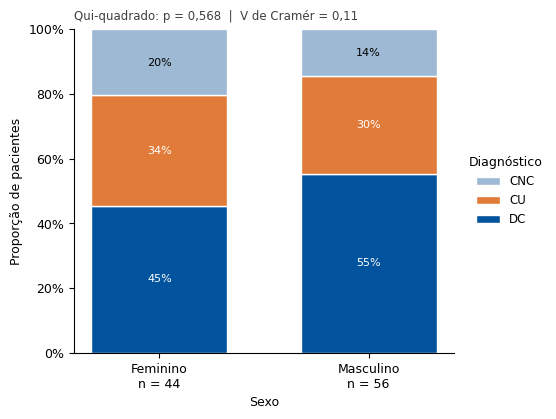

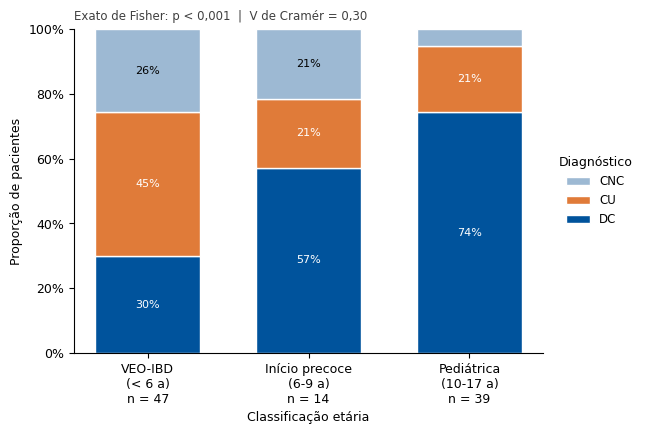

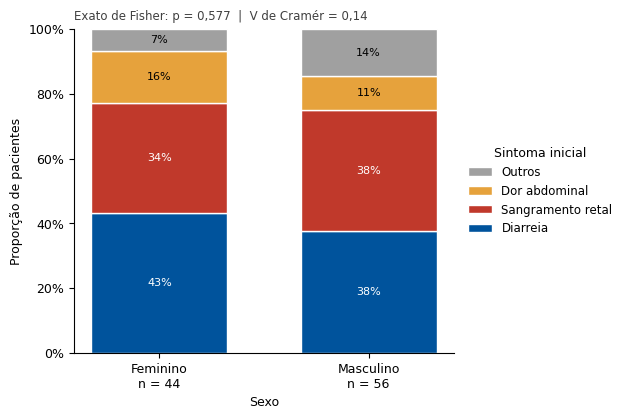

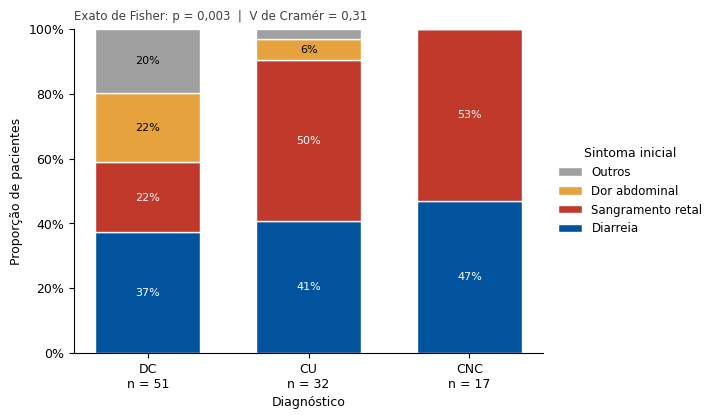

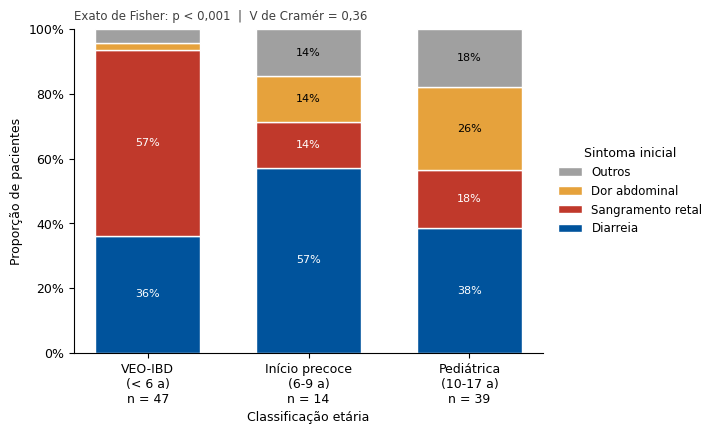


sexo x dx: Qui-quadrado p = 0.5676, V = 0.11
diagnostico    DC    CU   CNC
sexo                         
Feminino     45.5  34.1  20.5
Masculino    55.4  30.4  14.3

idade x dx: Exato de Fisher p = 0.0006, V = 0.30
diagnostico               DC    CU   CNC
classe_idade                            
VEO-IBD (< 6 a)         29.8  44.7  25.5
Início precoce (6-9 a)  57.1  21.4  21.4
Pediátrica (10-17 a)    74.4  20.5   5.1

sexo x sint: Exato de Fisher p = 0.5768, V = 0.14
sintoma    Diarreia  Sangramento retal  Dor abdominal  Outros
sexo                                                         
Feminino       43.2               34.1           15.9     6.8
Masculino      37.5               37.5           10.7    14.3

dx x sint: Exato de Fisher p = 0.0035, V = 0.31
sintoma      Diarreia  Sangramento retal  Dor abdominal  Outros
diagnostico                                                    
DC               37.3               21.6           21.6    19.6
CU               40.6               50.

In [ ]:
r_sexo_dx   = barras_empilhadas("sexo", "diagnostico", "fig_sexo_dx", "Sexo e diagnóstico")
r_idade_dx  = barras_empilhadas("classe_idade", "diagnostico", "fig_idade_dx", "Classificação etária e diagnóstico")
r_sexo_sint = barras_empilhadas("sexo", "sintoma", "fig_sexo_sintoma", "Sintoma inicial e sexo")
r_dx_sint   = barras_empilhadas("diagnostico", "sintoma", "fig_dx_sintoma", "Sintoma inicial e diagnóstico")
r_idade_sint = barras_empilhadas("classe_idade", "sintoma", "fig_idade_sintoma", "Sintoma inicial e classificação etária")

for nome, (r, tab, prop) in {"sexo x dx": r_sexo_dx, "idade x dx": r_idade_dx,
                             "sexo x sint": r_sexo_sint, "dx x sint": r_dx_sint,
                             "idade x sint": r_idade_sint}.items():
    print(f"\n{nome}: {r['teste']} p = {r['p']:.4f}, V = {r['ef']:.2f}")
    print((100 * prop).round(1).to_string())

## 5. Perda ponderal (sintoma inicial, diagnóstico e classificação etária)

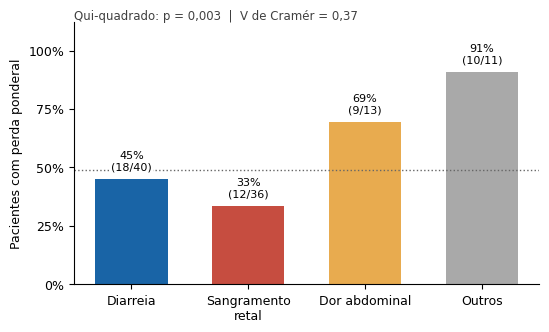

Sensibilidade (sem 'Perda ponderal'): Exato de Fisher p = 0.058


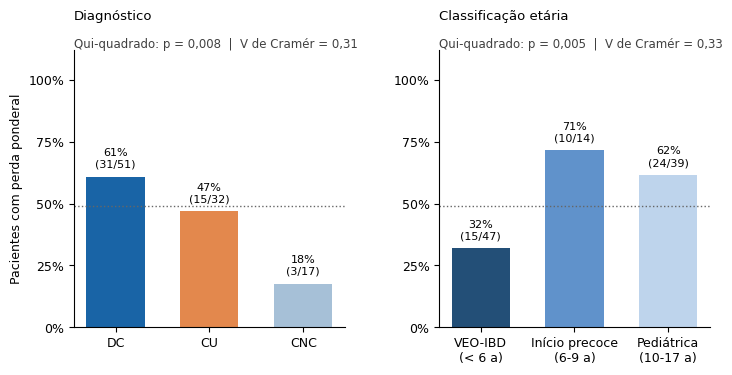

perda ponderal x sintoma: Qui-quadrado p = 0.0034, V = 0.37
perda ponderal x diagnóstico: Qui-quadrado p = 0.0083, V = 0.31
perda ponderal x classe: Qui-quadrado p = 0.0046, V = 0.33


In [ ]:
r_sint_pp = proporcao_ic("sintoma", "fig_sintoma_pp", "Sintoma inicial e perda ponderal")

# Sensibilidade: sem os 6 pacientes cujo sintoma inicial registrado é a própria perda ponderal
sub = dados[dados["sintoma_orig"] != "Perda ponderal"]
sens = teste_assoc(sub["sintoma"].cat.remove_unused_categories(), sub["perda_peso"])
print(f"Sensibilidade (sem 'Perda ponderal'): {sens['teste']} p = {sens['p']:.3f}")

fig, axs = plt.subplots(1, 2, figsize=(8.2, 3.6), gridspec_kw=dict(width_ratios=[3, 3], wspace=.35))
r_dx_pp = proporcao_ic("diagnostico", None, "Perda ponderal, diagnóstico e classificação etária",
                       ax=axs[0], titulo="Diagnóstico")
r_idade_pp = proporcao_ic("classe_idade", None, "Perda ponderal, diagnóstico e classificação etária",
                          ax=axs[1], titulo="Classificação etária")
axs[1].set_ylabel("")
salva(fig, "fig_pp_dx_idade")
for k, r in {"sintoma": r_sint_pp, "diagnóstico": r_dx_pp, "classe": r_idade_pp}.items():
    print(f"perda ponderal x {k}: {r['teste']} p = {r['p']:.4f}, V = {r['ef']:.2f}")

## 6. Tempo até o diagnóstico segundo grupos

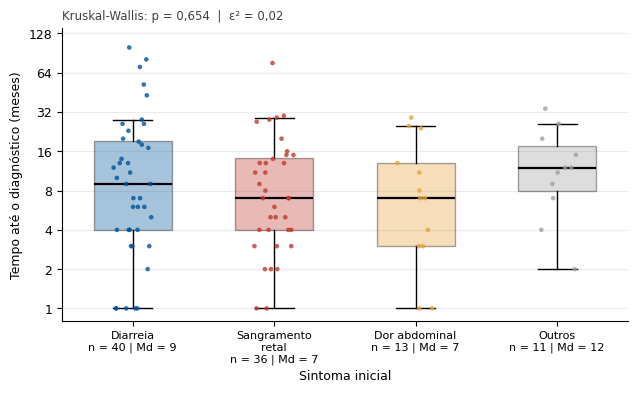

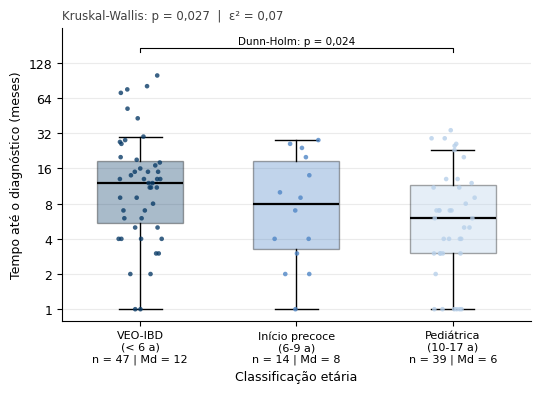

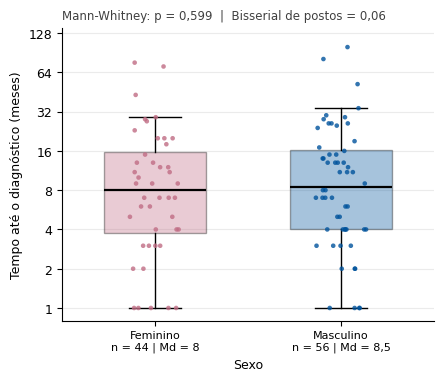

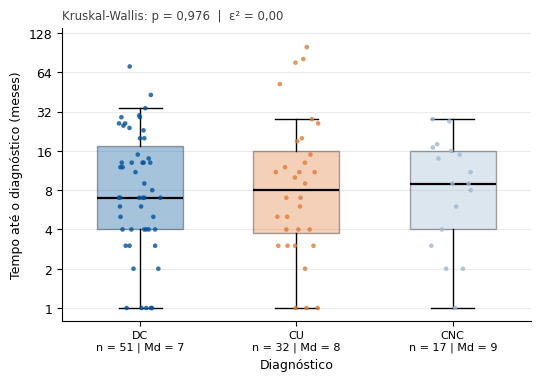

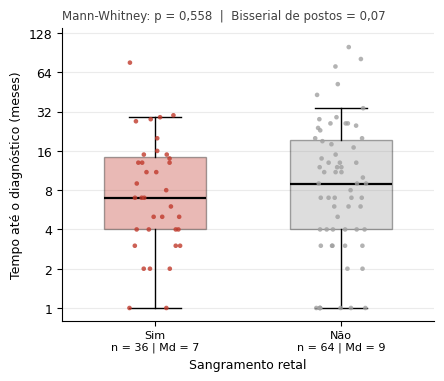

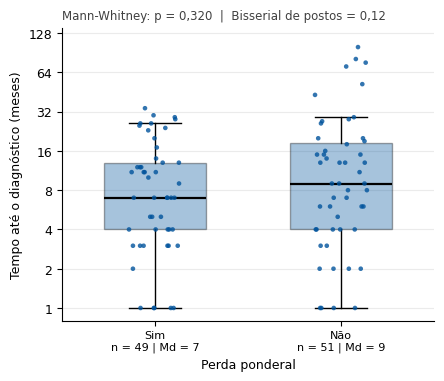

Tempo até diagnóstico (geral):
count    100.00
mean      13.95
std       17.19
min        1.00
25%        4.00
50%        8.50
75%       16.25
max      100.00
Name: t_dx, dtype: float64

sintoma: Kruskal-Wallis p = 0.6545, efeito = 0.016
  medianas: {'Diarreia': np.float64(9.0), 'Sangramento retal': np.float64(7.0), 'Dor abdominal': np.float64(7.0), 'Outros': np.float64(12.0)}
  IIQ: {'Diarreia': (np.float64(4.0), np.float64(19.25)), 'Sangramento retal': (np.float64(4.0), np.float64(14.25)), 'Dor abdominal': (np.float64(3.0), np.float64(13.0)), 'Outros': (np.float64(8.0), np.float64(17.5))}
                   a                  b       z       p  p_holm
0           Diarreia  Sangramento retal  0.5171  0.6051     1.0
1           Diarreia      Dor abdominal  0.6291  0.5293     1.0
2           Diarreia             Outros -0.7672  0.4429     1.0
3  Sangramento retal      Dor abdominal  0.2536  0.7998     1.0
4  Sangramento retal             Outros -1.1030  0.2700     1.0
5      Dor abdomin

In [ ]:
r_t_sint  = boxplot_tempo("sintoma", "fig_tempo_sintoma", "Sintoma inicial e tempo até o diagnóstico")
r_t_idade = boxplot_tempo("classe_idade", "fig_tempo_idade", "Classificação etária e tempo até o diagnóstico")
r_t_sexo  = boxplot_tempo("sexo", "fig_tempo_sexo", "Sexo e tempo até o diagnóstico")
r_t_dx    = boxplot_tempo("diagnostico", "fig_tempo_dx", "Diagnóstico e tempo até o diagnóstico")
r_t_sang  = boxplot_tempo("sangramento", "fig_tempo_sangramento", "Sangramento retal e tempo até o diagnóstico")
r_t_pp    = boxplot_tempo("perda_peso", "fig_tempo_pp", "Perda ponderal e tempo até o diagnóstico")

print("Tempo até diagnóstico (geral):"); print(dados["t_dx"].describe().round(2))
for k, r in {"sintoma": r_t_sint, "classe": r_t_idade, "sexo": r_t_sexo, "dx": r_t_dx,
             "sangramento": r_t_sang, "perda ponderal": r_t_pp}.items():
    med = {n: np.median(g) for n, g in zip(r["niveis"], r["grupos"])}
    iqr = {n: (np.percentile(g, 25), np.percentile(g, 75)) for n, g in zip(r["niveis"], r["grupos"])}
    print(f"\n{k}: {r['teste']} p = {r['p']:.4f}, efeito = {r['ef']:.3f}\n  medianas: {med}\n  IIQ: {iqr}")
    if r["dunn"] is not None:
        print(r["dunn"].round(4).to_string())

## 7. Idade de início: tempo até o diagnóstico e diagnóstico

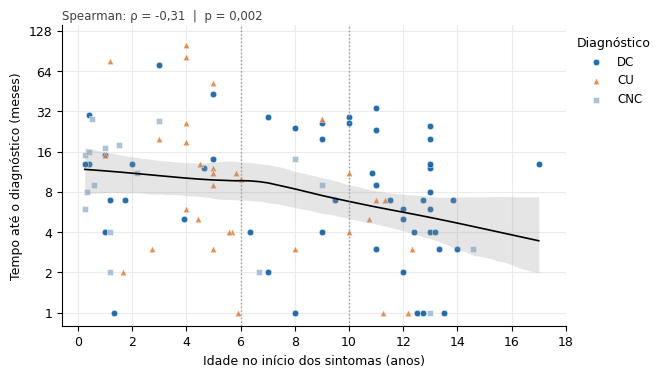

Spearman idade x tempo: rho = -0.311, p = 0.0016


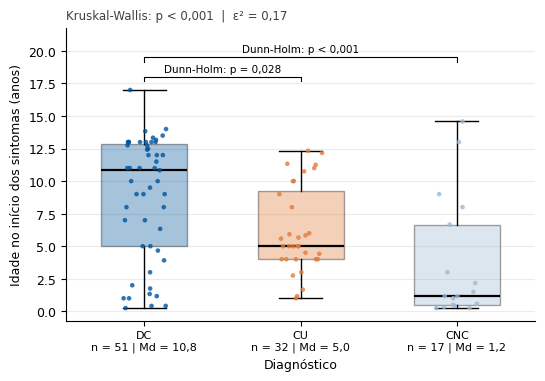

Idade x diagnóstico: p = 0.00018
    a    b        z        p   p_holm
0  DC   CU  2.45224  0.01420  0.02839
1  DC  CNC  3.94763  0.00008  0.00024
2  CU  CNC  1.84103  0.06562  0.06562
{'DC': (np.float64(10.833333333333334), np.float64(5.0), np.float64(12.875)), 'CU': (np.float64(5.0), np.float64(4.0), np.float64(9.25)), 'CNC': (np.float64(1.1666666666666667), np.float64(0.5), np.float64(6.666666666666667))}


In [ ]:
rho, p_rho = stats.spearmanr(dados["idade_inicio"], dados["t_dx"])
registra("Idade de início e tempo até o diagnóstico",
         "Idade de início $\\times$ tempo até o diagnóstico",
         dict(teste="Correlação de Spearman", p=p_rho, ef=rho, ef_nome="$\\rho$"))

x, y = dados["idade_inicio_anos"].values, dados["t_dx"].values
grade = np.linspace(x.min(), x.max(), 100)
suave = lambda xx, yy: np.interp(grade, *lowess(yy, xx, frac=0.75, return_sorted=True).T)
ajuste = suave(x, np.log2(y))
boot = np.array([suave(x[i], np.log2(y[i])) for i in
                 (rng.integers(0, len(x), len(x)) for _ in range(500))])
lo, hi = np.percentile(boot, [2.5, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(6.5, 3.9))
for dx, mk in zip(NIV_DX, ["o", "^", "s"]):
    m = (dados["diagnostico"] == dx).values
    ax.scatter(x[m], y[m], marker=mk, color=CORES["diagnostico"][dx], alpha=.85, s=22,
               edgecolor="white", linewidth=.4, label=dx)
ax.fill_between(grade, 2**lo, 2**hi, color="0.6", alpha=.25, linewidth=0)
ax.plot(grade, 2**ajuste, color="black", linewidth=1.2)
ax.axvline(6, color="0.6", linestyle=":", linewidth=1); ax.axvline(10, color="0.6", linestyle=":", linewidth=1)
eixo_log2(ax); ax.set_xticks(range(0, 19, 2))
ax.set_xlabel("Idade no início dos sintomas (anos)"); ax.set_ylabel("Tempo até o diagnóstico (meses)")
ax.legend(title="Diagnóstico", frameon=False, loc="upper left", bbox_to_anchor=(1, 1))
ax.text(0, 1.02, f"Spearman: ρ = {fnum(rho, 2)}  |  {ptxt(p_rho)}", transform=ax.transAxes,
        fontsize=8.5, color="0.25")
ax.grid(color="0.92"); ax.set_axisbelow(True)
salva(fig, "fig_idade_tempo")
print(f"Spearman idade x tempo: rho = {rho:.3f}, p = {p_rho:.4f}")

# Idade de início segundo o diagnóstico (comparação nova)
r_idade_cont_dx = boxplot_tempo("diagnostico", "fig_idade_dx_continua", "Idade de início e diagnóstico",
                                y="idade_inicio_anos", ylabel="Idade no início dos sintomas (anos)",
                                log=False, var_nome="idade de início")
print(f"Idade x diagnóstico: p = {r_idade_cont_dx['p']:.5f}")
print(r_idade_cont_dx["dunn"].round(5).to_string())
print({n: (np.median(g), np.percentile(g, 25), np.percentile(g, 75))
       for n, g in zip(r_idade_cont_dx["niveis"], r_idade_cont_dx["grupos"])})

## 8. Tempo até a consulta × tempo até a colonoscopia

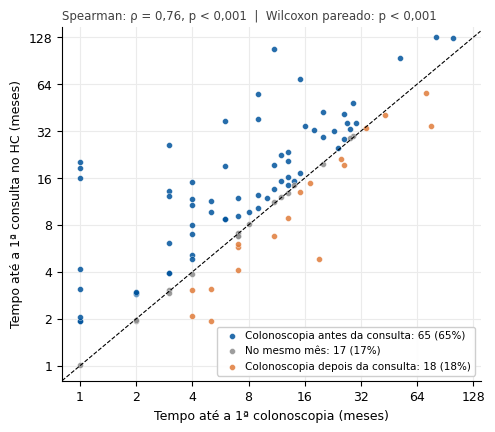

n = 100; rho = 0.756; Wilcoxon p = 2.03e-07; antes/igual/depois = 65/17/18
Medianas: consulta 12.5 | colono 8.5 | diferença 2.0 (np.float64(0.0), np.float64(9.0))


In [ ]:
cc = dados.dropna(subset=["t_consulta"])
rho_cc, p_cc = stats.spearmanr(cc["t_consulta"], cc["t_dx"])
dif = cc["t_consulta"] - cc["t_dx"]
wx = stats.wilcoxon(cc["t_consulta"], cc["t_dx"], zero_method="wilcox", correction=True, method="approx")
registra("Tempo até a consulta e tempo até a colonoscopia",
         "Tempo até a consulta $\\times$ tempo até a colonoscopia",
         dict(teste="Correlação de Spearman", p=p_cc, ef=rho_cc, ef_nome="$\\rho$"))
registra("Tempo até a consulta e tempo até a colonoscopia",
         "Tempo até a consulta $-$ tempo até a colonoscopia (pareado)",
         dict(teste="Wilcoxon pareado", p=wx.pvalue, ef=np.nan, ef_nome=""))

antes, igual, depois = (dif > 0).sum(), (dif == 0).sum(), (dif < 0).sum()
fig, ax = plt.subplots(figsize=(5.4, 4.6))
ax.plot([0.8, 140], [0.8, 140], "--", color="black", linewidth=.8)
jit = np.exp(rng.uniform(-.04, .04, len(cc)))
for mask, cor, rot in [(dif > 0, AZUL, "Colonoscopia antes da consulta"),
                       (dif == 0, "0.55", "No mesmo mês"),
                       (dif < 0, "#E07B39", "Colonoscopia depois da consulta")]:
    k = int(mask.sum())
    ax.scatter(cc["t_dx"][mask], (cc["t_consulta"] * jit)[mask], s=18, color=cor, alpha=.85,
               edgecolor="white", linewidth=.3, label=f"{rot}: {k} ({fnum(100 * k / len(cc), 0)}%)")
eixo_log2(ax, "x"); eixo_log2(ax, "y", lim=(0.8, 150))
ax.set_xlabel("Tempo até a 1ª colonoscopia (meses)"); ax.set_ylabel("Tempo até a 1ª consulta no HC (meses)")
ax.legend(loc="lower right", fontsize=7.5, frameon=True, framealpha=.95, edgecolor="0.8", handletextpad=.3)
ax.text(0, 1.02, f"Spearman: ρ = {fnum(rho_cc, 2)}, {ptxt(p_cc)}  |  Wilcoxon pareado: {ptxt(wx.pvalue)}",
        transform=ax.transAxes, fontsize=8.5, color="0.25")
ax.grid(color="0.92"); ax.set_axisbelow(True)
salva(fig, "fig_consulta_colono")
print(f"n = {len(cc)}; rho = {rho_cc:.3f}; Wilcoxon p = {wx.pvalue:.2e}; antes/igual/depois = {antes}/{igual}/{depois}")
print("Medianas: consulta", cc["t_consulta"].median(), "| colono", cc["t_dx"].median(),
      "| diferença", dif.median(), (dif.quantile(.25), dif.quantile(.75)))

## 9. Sangramento retal e tempo até o diagnóstico, estratificado pela classificação etária

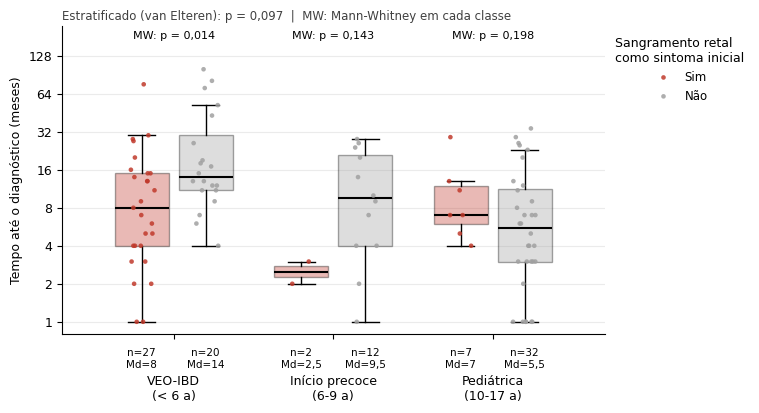

VEO-IBD (< 6 a) p = 0.0145 {'Sim': (27, np.float64(8.0)), 'Não': (20, np.float64(14.0))}
Início precoce (6-9 a) p = 0.1432 {'Sim': (2, np.float64(2.5)), 'Não': (12, np.float64(9.5))}
Pediátrica (10-17 a) p = 0.1982 {'Sim': (7, np.float64(7.0)), 'Não': (32, np.float64(5.5))}
van Elteren: z = -1.66, p = 0.0969


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
larg, desloc = 0.34, 0.2
p_estrato = {}
for i, k in enumerate(NIV_IDADE):
    s = dados[dados["classe_idade"] == k]
    for j, (sg, dx_) in enumerate(zip(NIV_SN, [-desloc, desloc])):
        v = s.loc[s["sangramento"] == sg, "t_dx"].values
        bp = ax.boxplot([v], positions=[i + dx_], widths=larg, showfliers=False, patch_artist=True,
                        medianprops=dict(color="black", linewidth=1.5))
        bp["boxes"][0].set_facecolor(CORES["sangramento"][sg]); bp["boxes"][0].set_alpha(.35)
        ax.scatter(i + dx_ + rng.uniform(-.08, .08, len(v)), v, s=11,
                   color=CORES["sangramento"][sg], alpha=.85, edgecolor="none", zorder=3,
                   label=sg if i == 0 else None)
        ax.text(i + dx_, 0.62, f"n={len(v)}\nMd={fmed(np.median(v))}", ha="center", va="top", fontsize=7.5)
    rk = compara_grupos(s["t_dx"], s["sangramento"])
    p_estrato[k] = rk
    ax.text(i, 175, f"MW: {ptxt(rk['p'])}", ha="center", fontsize=8)
ve = van_elteren(dados["t_dx"], dados["sangramento"], dados["classe_idade"])
registra("Sangramento retal e tempo, estratificado pela classificação etária",
         "Sangramento retal $\\times$ tempo até o diagnóstico (ajustado pela classe etária)",
         dict(teste="van Elteren", p=ve["p"], ef=np.nan, ef_nome=""))
eixo_log2(ax, lim=(0.8, 220))
ax.set_xticks(range(3), [k.replace(" (", "\n(") for k in NIV_IDADE])
ax.tick_params(axis="x", pad=26)
ax.set_ylabel("Tempo até o diagnóstico (meses)")
ax.legend(title="Sangramento retal\ncomo sintoma inicial", frameon=False, loc="upper left", bbox_to_anchor=(1, 1))
ax.text(0, 1.02, f"Estratificado (van Elteren): {ptxt(ve['p'])}  |  MW: Mann-Whitney em cada classe",
        transform=ax.transAxes, fontsize=8.5, color="0.25")
ax.grid(axis="y", color="0.92"); ax.set_axisbelow(True)
salva(fig, "fig_tempo_sangramento_estrat")
for k, r in p_estrato.items():
    print(k, f"p = {r['p']:.4f}", {n: (len(g), np.median(g)) for n, g in zip(r["niveis"], r["grupos"])})
print(f"van Elteren: z = {ve['z']:.2f}, p = {ve['p']:.4f}")

## 10. Tabela-resumo de todos os testes (única tabela mantida)

In [ ]:
res = pd.DataFrame(resumo).drop_duplicates(subset=["variaveis", "teste"])
TESTE_CURTO = {"Qui-quadrado": "Qui-quadrado", "Exato de Fisher": "Fisher",
               "Correlação de Spearman": "Spearman", "Wilcoxon pareado": "Wilcoxon pareado"}
EF_CURTO = {"V de Cramér": "V", "Bisserial de postos": "r_{bp}", "$\\varepsilon^2$": "\\varepsilon^2",
            "$\\rho$": "\\rho"}
def bloco(v):
    if "consulta" in v:
        return "Tempo até a consulta e tempo até a colonoscopia"
    if "tempo até o diagnóstico" in v:
        return "Tempo até o diagnóstico"
    return "Características demográficas e clínicas"
res["bloco"] = res["variaveis"].map(bloco)
linhas = []
for nome_bloco in ["Características demográficas e clínicas", "Tempo até o diagnóstico",
                   "Tempo até a consulta e tempo até a colonoscopia"]:
    linhas.append(f"\\addlinespace\\multicolumn{{4}}{{l}}{{\\textbf{{{nome_bloco}}}}} \\\\")
    for _, r in res[res["bloco"] == nome_bloco].iterrows():
        if np.isnan(r["ef"]):
            ef = "--"
        else:
            ef = f"${EF_CURTO[r['ef_nome']]} = {fnum(r['ef'], 2).replace(',', '{,}')}$"
        p = ptex(r["p"])
        if r["p"] < 0.05:
            p = "\\textbf{" + p + "}"
        var = (r["variaveis"].replace(" $\\times$ tempo até o diagnóstico", "")
               .replace(" (ajustado pela classe etária)", ", por classe etária")
               .replace("Tempo até a consulta $\\times$ tempo até a colonoscopia", "Correlação entre os dois tempos")
               .replace("Tempo até a consulta $-$ tempo até a colonoscopia (pareado)", "Diferença pareada entre os dois tempos"))
        linhas.append(f"\\quad {var} & {TESTE_CURTO.get(r['teste'], r['teste'])} & {p} & {ef} \\\\")
tex = ["\\begin{table}[H]", "\\centering", "\\small",
       "\\caption{Resumo dos testes da análise bivariada}",
       "\\label{tab:resumo_testes}", "\\begin{threeparttable}",
       "\\begin{tabular}{p{7.4cm}lcc}", "\\toprule",
       "Variáveis & Teste & $p$ & Efeito \\\\", "\\midrule", *linhas,
       "\\bottomrule", "\\end{tabular}",
       "\\begin{tablenotes}\\footnotesize",
       "\\item Em negrito, $p < 0{,}05$. No bloco \\emph{Tempo até o diagnóstico}, cada linha indica a variável "
       "comparada com o tempo até o diagnóstico. Efeito: $V$ de Cramér (variáveis categóricas); "
       "$\\varepsilon^2$ (Kruskal-Wallis); $r_{bp}$, correlação bisserial de postos em módulo (Mann-Whitney); "
       "$\\rho$ de Spearman (correlações). O teste de van Elteren compara os grupos dentro de cada classe "
       "etária e combina os resultados.",
       "\\end{tablenotes}", "\\end{threeparttable}", "\\end{table}"]
with open("tabelas/tab_resumo_testes.tex", "w", encoding="utf-8") as f:
    f.write("\n".join(tex) + "\n")
print(res[["variaveis", "teste", "p", "ef"]].round(4).to_string())

                                                                           variaveis                   teste       p      ef
0                                                          Sexo $\times$ diagnóstico            Qui-quadrado  0.5676  0.1064
1                                          Classificação etária $\times$ diagnóstico         Exato de Fisher  0.0006  0.3024
2                                                      Sexo $\times$ sintoma inicial         Exato de Fisher  0.5768  0.1428
3                                               Diagnóstico $\times$ sintoma inicial         Exato de Fisher  0.0035  0.3137
4                                      Classificação etária $\times$ sintoma inicial         Exato de Fisher  0.0001  0.3569
5                                            Sintoma inicial $\times$ perda ponderal            Qui-quadrado  0.0034  0.3695
6                                                Diagnóstico $\times$ perda ponderal            Qui-quadrado  0.0083  0.3095


## 11. Baixar figuras e tabela

In [ ]:
os.makedirs("resultados_bivariada", exist_ok=True)
for pasta in ("tabelas", "figuras"):
    shutil.copytree(pasta, os.path.join("resultados_bivariada", pasta), dirs_exist_ok=True)
shutil.make_archive("resultados_bivariada", "zip", "resultados_bivariada")
print("Arquivos gerados:", sorted(glob.glob("tabelas/*") + glob.glob("figuras/*")))
try:
    from google.colab import files
    files.download("resultados_bivariada.zip")
except ImportError:
    pass

Arquivos gerados: ['figuras/fig_consulta_colono.pdf', 'figuras/fig_dx_sintoma.pdf', 'figuras/fig_idade_dx.pdf', 'figuras/fig_idade_dx_continua.pdf', 'figuras/fig_idade_sintoma.pdf', 'figuras/fig_idade_tempo.pdf', 'figuras/fig_pp_dx_idade.pdf', 'figuras/fig_sexo_dx.pdf', 'figuras/fig_sexo_sintoma.pdf', 'figuras/fig_sintoma_pp.pdf', 'figuras/fig_tempo_dx.pdf', 'figuras/fig_tempo_idade.pdf', 'figuras/fig_tempo_pp.pdf', 'figuras/fig_tempo_sangramento.pdf', 'figuras/fig_tempo_sangramento_estrat.pdf', 'figuras/fig_tempo_sexo.pdf', 'figuras/fig_tempo_sintoma.pdf', 'tabelas/tab_resumo_testes.tex']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>